# AI 4 Life Science - Unsupervised Representation Learning - Tutorial 1: Introduction and VAEs

## Setup and Groups

Form groups of 3, ideally with people you do not work with regularly. Take 5 min each to explain a bit about your work:

1. What is the focus of your work?

2. What is the limitation or most difficult technical aspect?

3. Could unsupervised learning fit into your project in any way? If so, where could it improve things. If not, why is it unhelpful and what do you wish it could do?


To explore unsupervised learning with code, you can either set up this notebook on your university/lab computer, run it locally, or import it to colab. If you wish to run locally, but do not have anything set up on your machine, we recommend uv for a quick and easy setup:  
https://docs.astral.sh/uv/getting-started/installation/  
After installing uv, you can start a project: https://docs.astral.sh/uv/guides/projects/  
and start up the jupyter notebook with this guide: https://docs.astral.sh/uv/guides/integration/jupyter/  
We will include uv package installation commands throughout (as suggestions), but you are of course free to use your existing environments or preferred packages.

# Data

If you have your own imaging data, setup a data loader or manually load a handful of samples. Ideally choose data that you can compare, e.g. a few different classes or segmentations etc.

If you do not have your own imaging data, you can consider using synthetic test data we have created (or create your own!).  
Our data is hosted at: https://huggingface.co/datasets/Jemtan11/AADD   
And the abdominal test data (recommended) can be found here: https://huggingface.co/datasets/Jemtan11/AADD/tree/main/abdom/test  
Navigate to the different test classes and download one sample per class.

**Alternatively** you can skip down to the model section and select a public dataset associated with that model.

## Reproducible environment check

Select the **Python 3.12 (AI4LS URL)** kernel. The required packages have already been installed in `.venv`. If `medvae` is missing in a fresh environment, uncomment the installation command below.


In [1]:
# Run only if MedVAE is not installed in the selected kernel:
# import sys
# !uv pip install --python {sys.executable} medvae

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
from medvae import MVAE

print('[TRACE 1/7] Environment ready')
print('Python:', sys.executable)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())


/config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[TRACE 1/7] Environment ready
Python: /config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/bin/python
PyTorch: 2.13.0+cu130
CUDA available: False


## Load and inspect the AADD brain volume

This uses the single downloaded sample rather than the complete AADD dataset.


In [2]:
file_path = Path('data/class0/aadd_00000.nii.gz')
if not file_path.exists():
    raise FileNotFoundError(f'Missing input file: {file_path.resolve()}')

nii = nib.load(file_path)
nii = nib.as_closest_canonical(nii)
img_data = torch.from_numpy(nii.get_fdata(dtype=np.float32))
img_data_r = torch.movedim(img_data, 1, 0).rot90(dims=(-2, -1))

print('[TRACE 2/7] Input loaded')
print('Path:', file_path.resolve())
print('Shape:', tuple(img_data.shape))
print('Intensity range:', float(img_data.min()), float(img_data.max()))
print('Voxel spacing:', nii.header.get_zooms()[:3])


[TRACE 2/7] Input loaded
Path: /config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/data/class0/aadd_00000.nii.gz
Shape: (256, 256, 256)
Intensity range: 0.0 0.8637577891349792
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


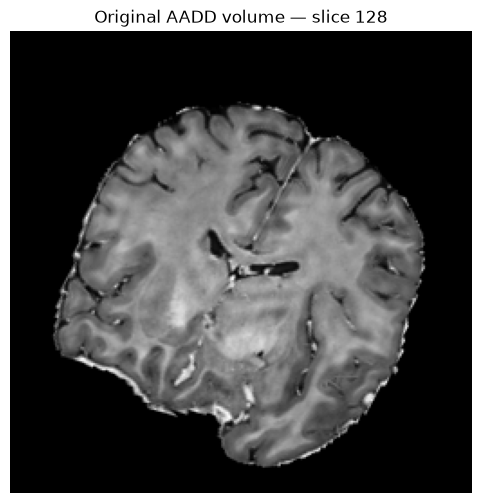

[TRACE 3/7] Original middle slice displayed


In [3]:
slice_index = img_data_r.shape[0] // 2
plt.figure(figsize=(6, 6))
plt.imshow(img_data_r[slice_index], cmap='gray')
plt.title(f'Original AADD volume — slice {slice_index}')
plt.axis('off')
plt.show()
print('[TRACE 3/7] Original middle slice displayed')


# Model

To save time and compute, we suggest finding a pre-trained VAE, perhaps one of the following:  
https://github.com/NVIDIA-Medtech/NV-Generate-CTMR/blob/main/train_vae_tutorial.ipynb  
https://huggingface.co/stanfordmimi/MedVAE  
https://github.com/MIC-DKFZ/nnssl  (This is MAE instead of VAE but we will cover that later)   
https://github.com/lzl199704/vis-mae (MAE again)  
or find one more suitable for your type of data. You could also try training your own VAE from scratch on small images, e.g. MedMNIST data (https://medmnist.com/)  

Adjust your data to match the input format of your chosen model as best as you can. You can also consider downloading a portion of their training datasets to play with.

Consider:
1. How is the quality of the reconstructions? 
2. What aspects are missing? What aspects are reproduced faithully?
3. For the same input, generate multiple samples. How do the reconstructions differ?
4. Generate random samples from the prior distribution. How do they differ from your data?
5. Modify the latent space around a sample in a few random directions. How do the samples differ?
6. Are any of these variations relevant for your type of task?


## Small 2D variational autoencoder

The pretrained 3D MedVAE is too expensive for repeated CPU experiments on this machine. Instead, this section trains a compact 2D VAE on the nonblank axial slices of the downloaded volume.

- Input: one-channel `128 × 128` axial slices
- Encoder: three strided convolutions
- Latent representation: 16 values (`mu` and `logvar`)
- Decoder: one fully connected layer and three transposed convolutions
- Parameters: 417,721

A VAE is used rather than a deterministic autoencoder because the tutorial asks for repeated samples, prior sampling, and latent-space modifications. The full implementation is in `train_toy_vae.py`.


In [4]:
# Training takes about 30 seconds on this two-core CPU.
# Re-running this cell overwrites outputs/toy_vae with a reproducible run.
%run train_toy_vae.py --epochs 15 --latent-dim 16 --seed 42


[TRACE 1/8] Loading and preparing slices
Volume=(256, 256, 256); usable slices=207; train=166; val=41
[TRACE 2/8] Building TinyVAE
Device=cpu; parameters=417,721; latent_dim=16
[TRACE 3/8] Training
epoch=01 train=0.145379 val=0.120500
epoch=02 train=0.107522 val=0.068251
epoch=03 train=0.050682 val=0.032327
epoch=04 train=0.028932 val=0.024902
epoch=05 train=0.021318 val=0.018324
epoch=06 train=0.015864 val=0.014331
epoch=07 train=0.013304 val=0.012566
epoch=08 train=0.011761 val=0.011593
epoch=09 train=0.010784 val=0.010636
epoch=10 train=0.009673 val=0.009573
epoch=11 train=0.008605 val=0.008741
epoch=12 train=0.007902 val=0.008232
epoch=13 train=0.007450 val=0.007896
epoch=14 train=0.007129 val=0.007624
epoch=15 train=0.006863 val=0.007424
[TRACE 4/8] Computing reconstructions and metrics
[TRACE 5/8] Sampling repeated reconstructions and the prior
[TRACE 6/8] Traversing and interpolating latent space
[TRACE 7/8] Running UMAP and representation comparison


/config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[TRACE 8/8] Complete
{
  "parameters": 417721,
  "epochs": 15,
  "train_seconds": 28.622093888930976,
  "usable_slices": 207,
  "final_train_loss": 0.0068626020227121306,
  "final_validation_loss": 0.007424251335423167,
  "mae": 0.03951358422636986,
  "mse": 0.00627258513122797,
  "psnr_db": 22.025534357492383,
  "latent_silhouette_proxy": 0.33602988719940186,
  "image_silhouette_proxy": 0.24903765320777893,
  "proxy_group_warning": "Slice-position thirds are not true biological or diagnostic classes."
}
Artifacts: /config/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/outputs/toy_vae


## Load the trained model and results

The following cell reloads the saved checkpoint, demonstrating that the result is reusable without retraining.


In [5]:
import json
from IPython.display import display, Image
from train_toy_vae import TinyVAE, load_slices

toy_output = Path('outputs/toy_vae')
checkpoint = torch.load(toy_output / 'tiny_vae.pt', map_location='cpu', weights_only=True)
toy_model = TinyVAE(checkpoint['latent_dim'])
toy_model.load_state_dict(checkpoint['model_state_dict'])
toy_model.eval()

toy_images, toy_slice_indices, _ = load_slices(file_path, checkpoint['image_size'])
metrics = json.loads((toy_output / 'metrics.json').read_text())

print('[TRACE] Trained checkpoint loaded')
for name, value in metrics.items():
    print(f'{name}: {value}')


[TRACE] Trained checkpoint loaded
parameters: 417721
epochs: 15
train_seconds: 28.622093888930976
usable_slices: 207
final_train_loss: 0.0068626020227121306
final_validation_loss: 0.007424251335423167
mae: 0.03951358422636986
mse: 0.00627258513122797
psnr_db: 22.025534357492383
latent_silhouette_proxy: 0.33602988719940186
image_silhouette_proxy: 0.24903765320777893


### 1–2. Reconstruction quality

The figure shows original slices, deterministic reconstructions using the posterior mean, and absolute errors. MAE, MSE, and PSNR quantify fidelity. Expect the VAE to preserve large brain structures while smoothing fine texture and sharp boundaries because the latent has only 16 values.


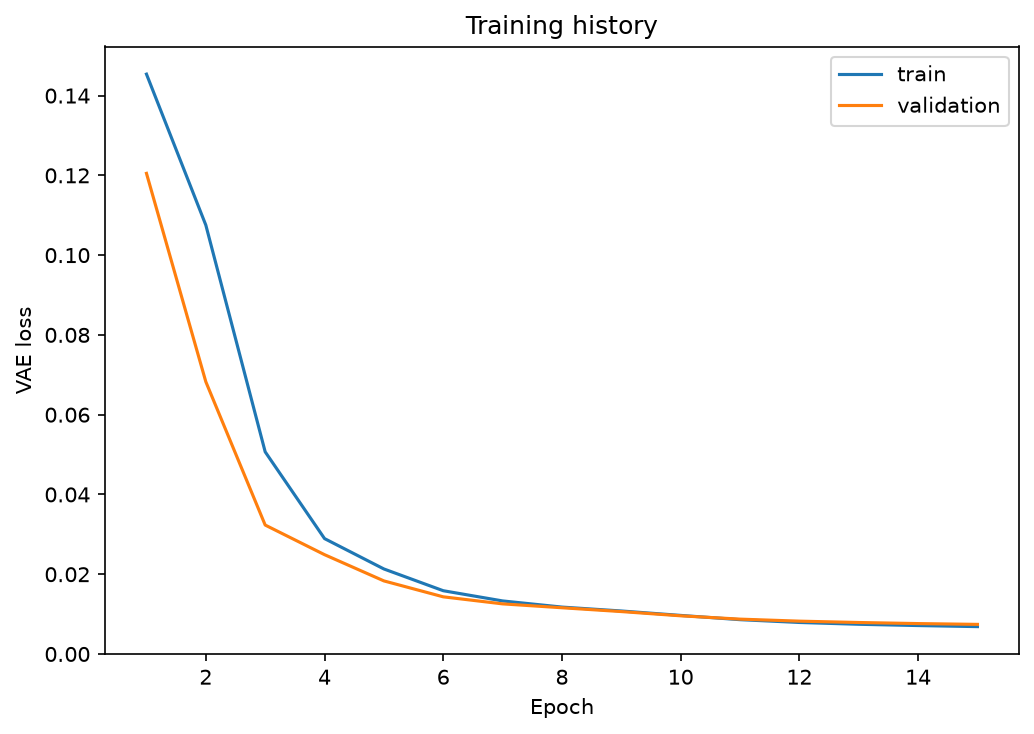

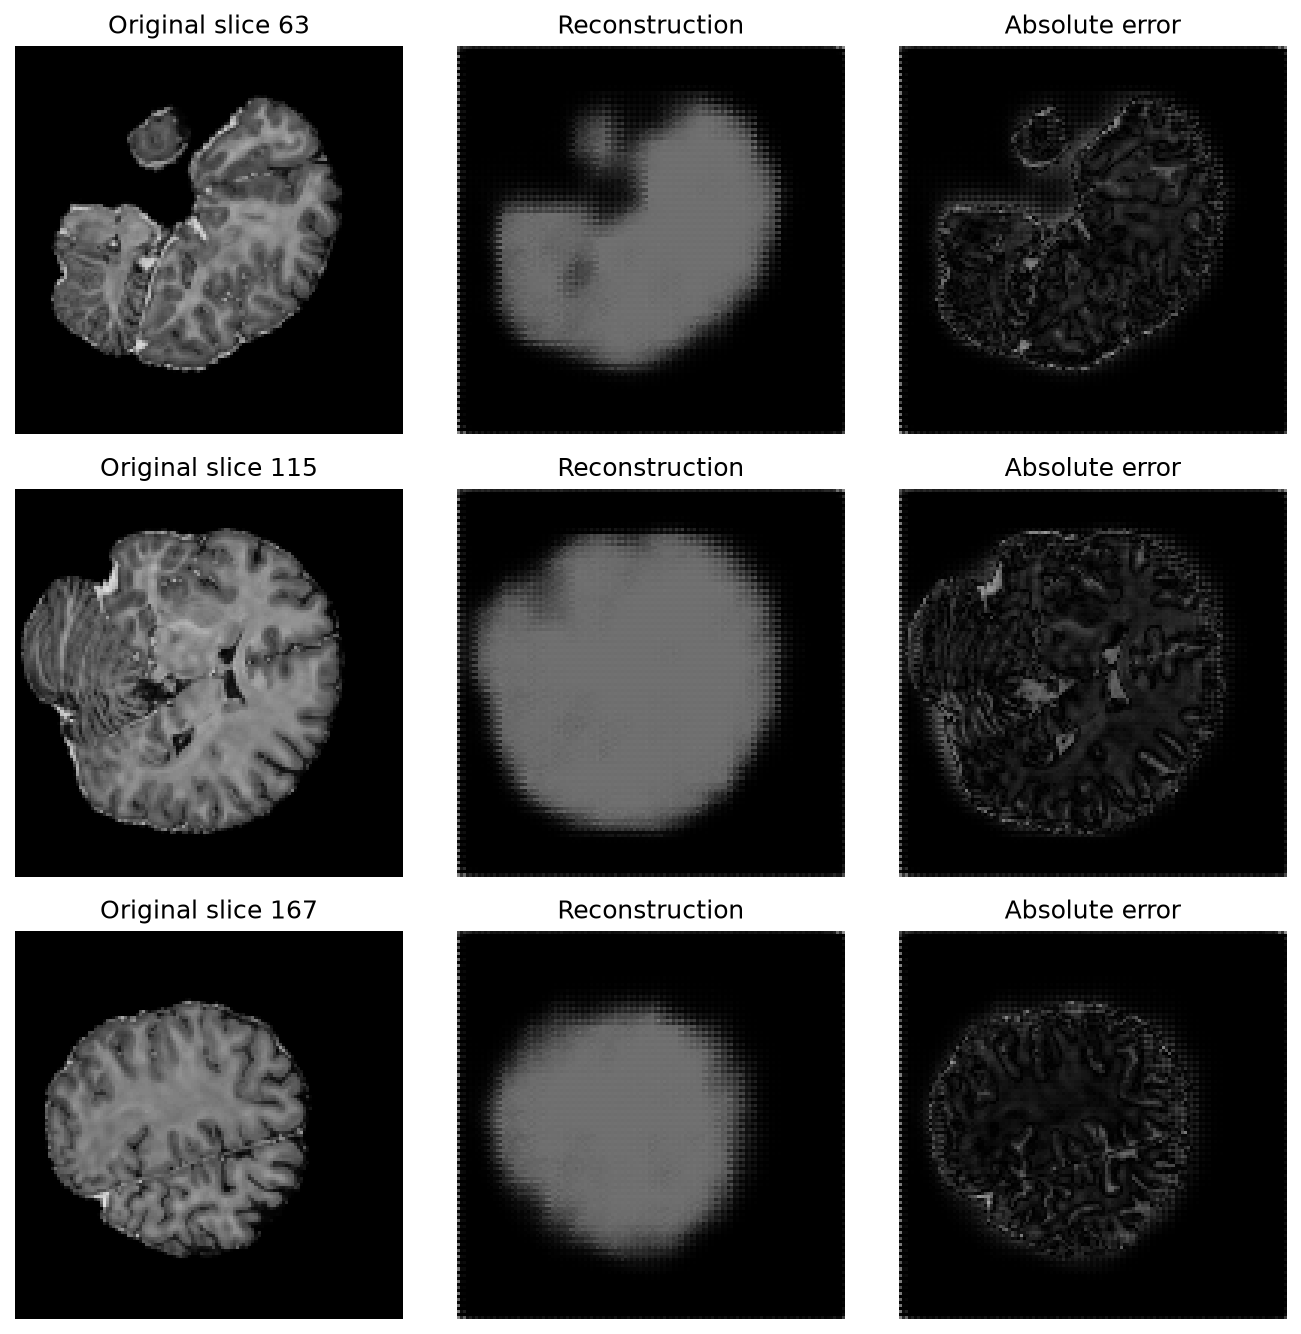

MAE: 0.0395
MSE: 0.0063
PSNR: 22.03 dB


In [6]:
display(Image(filename=str(toy_output / 'training_history.png')))
display(Image(filename=str(toy_output / 'reconstructions.png')))
print(f"MAE: {metrics['mae']:.4f}")
print(f"MSE: {metrics['mse']:.4f}")
print(f"PSNR: {metrics['psnr_db']:.2f} dB")


### 3. Multiple samples for the same input

The encoder predicts a Gaussian distribution. Sampling it repeatedly gives related but non-identical reconstructions. Differences indicate uncertainty/variation allowed by the learned posterior.


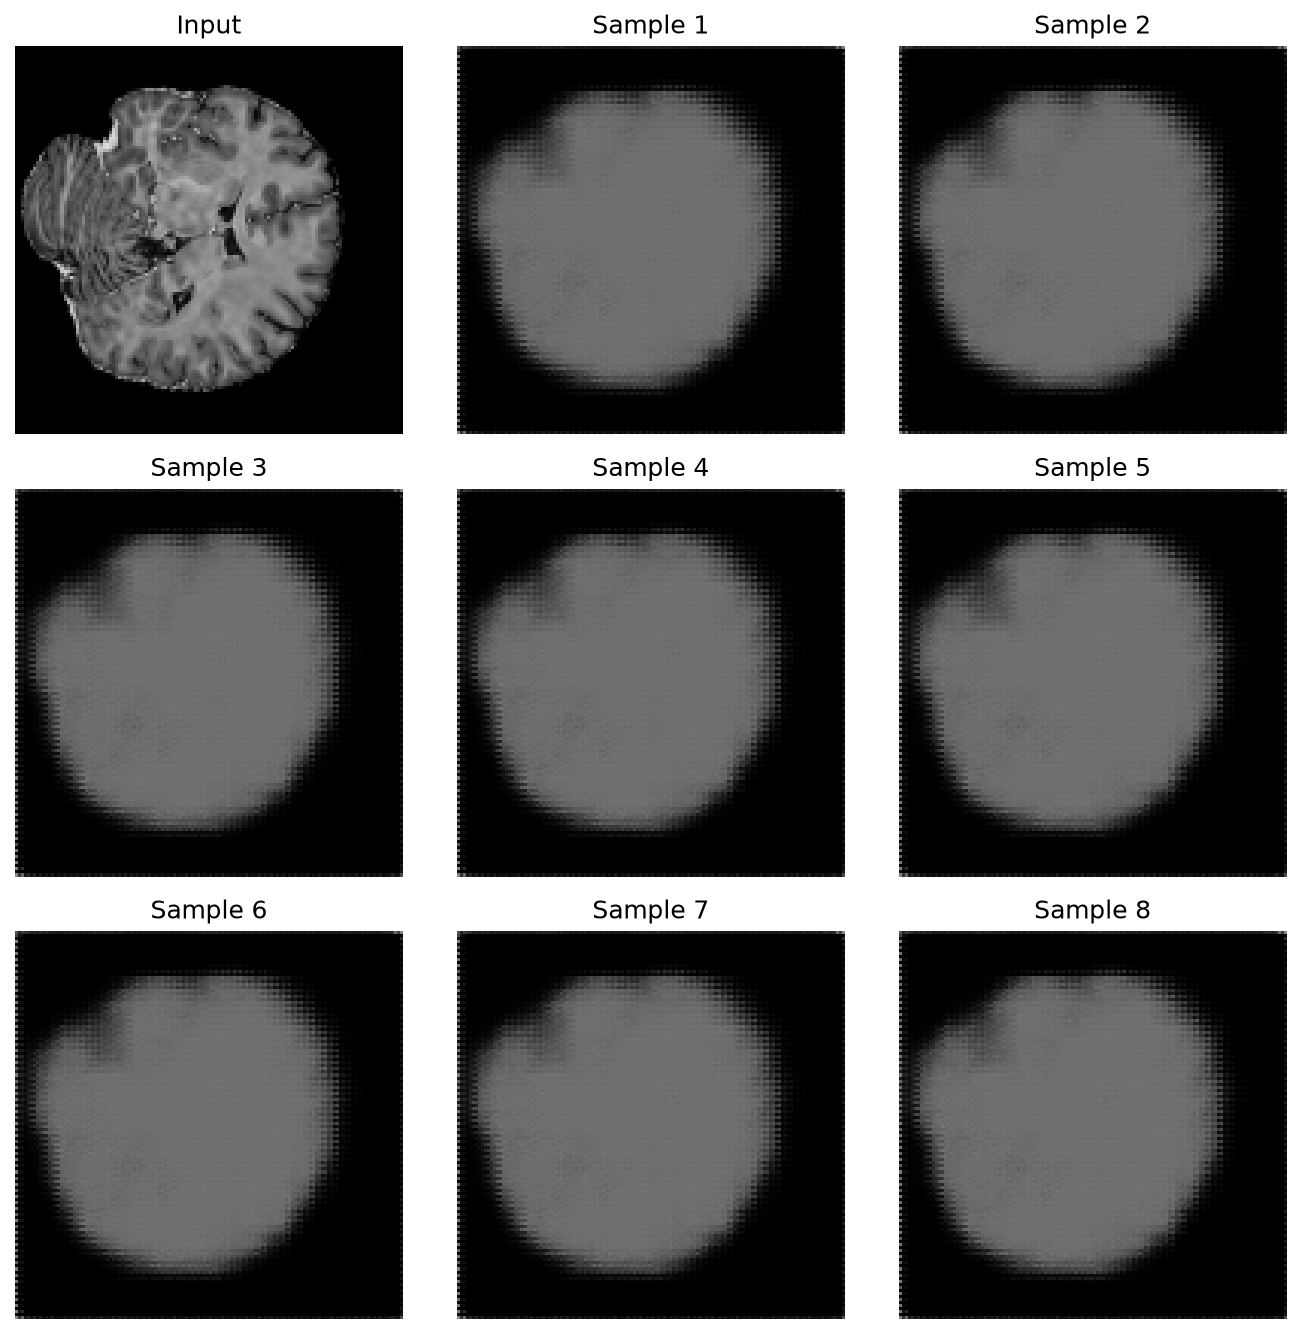

In [7]:
display(Image(filename=str(toy_output / 'repeated_reconstructions.png')))


### 4. Random samples from the prior

These images decode random vectors drawn from the assumed standard-normal prior. With only one volume and 15 training epochs, they may look blurrier or less anatomically plausible than reconstructions.


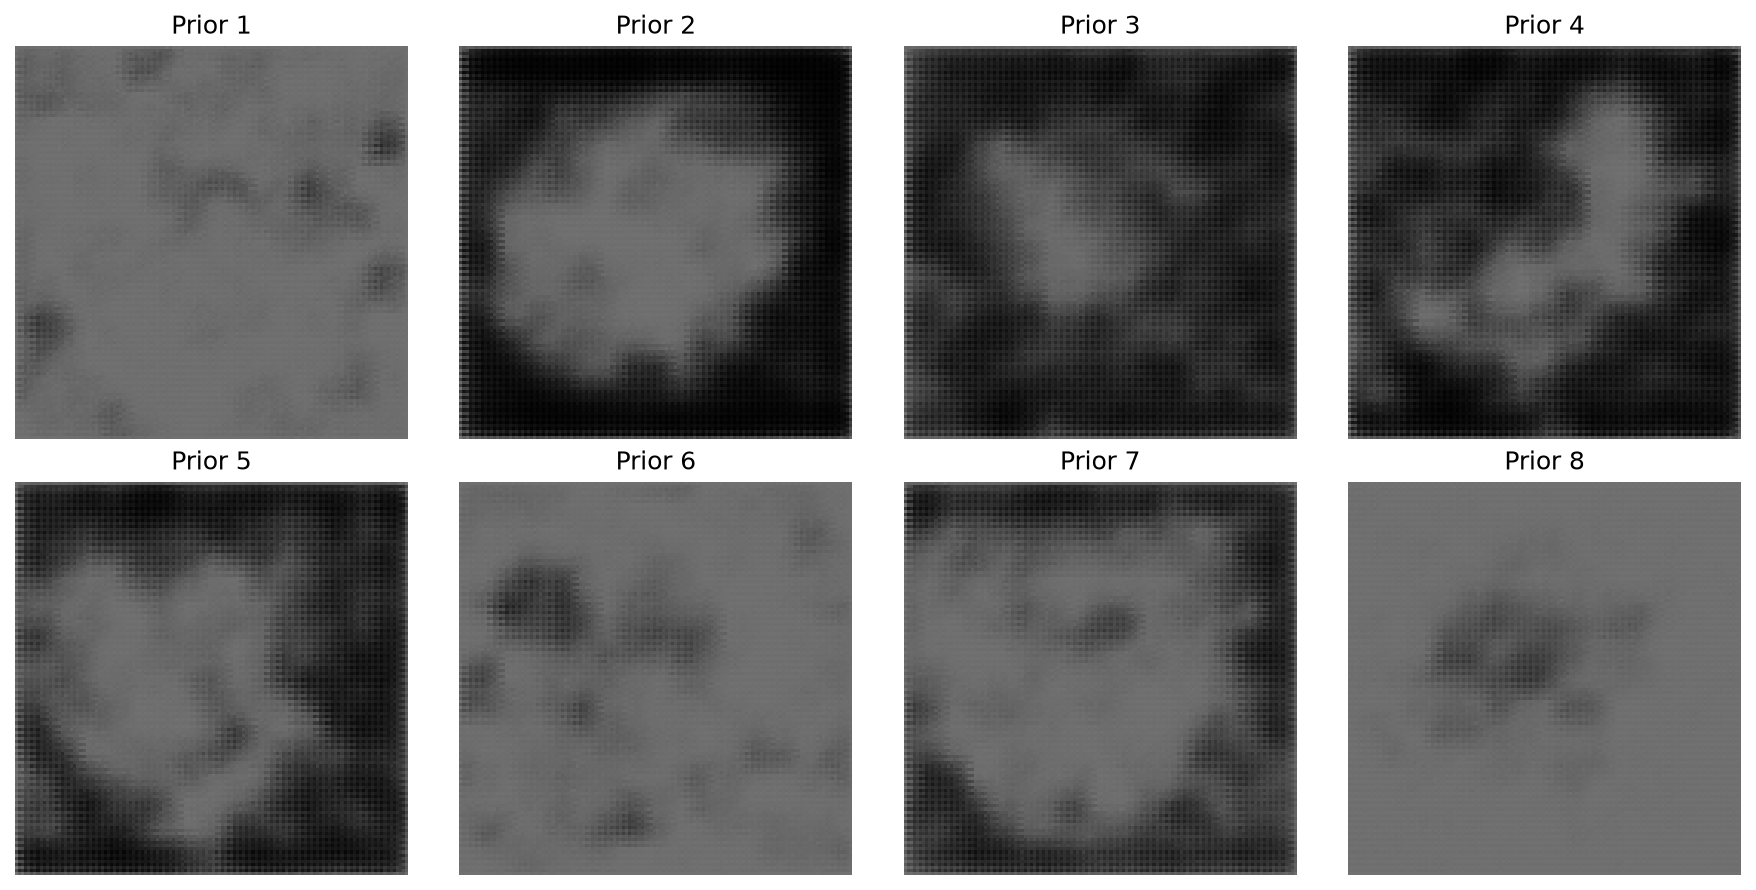

In [8]:
display(Image(filename=str(toy_output / 'prior_samples.png')))


### 5. Modify and interpolate the latent space

The traversal moves one encoded slice along a normalized random direction. The interpolation moves between latent means from two distant axial slices. Smooth image changes suggest a locally organized representation.


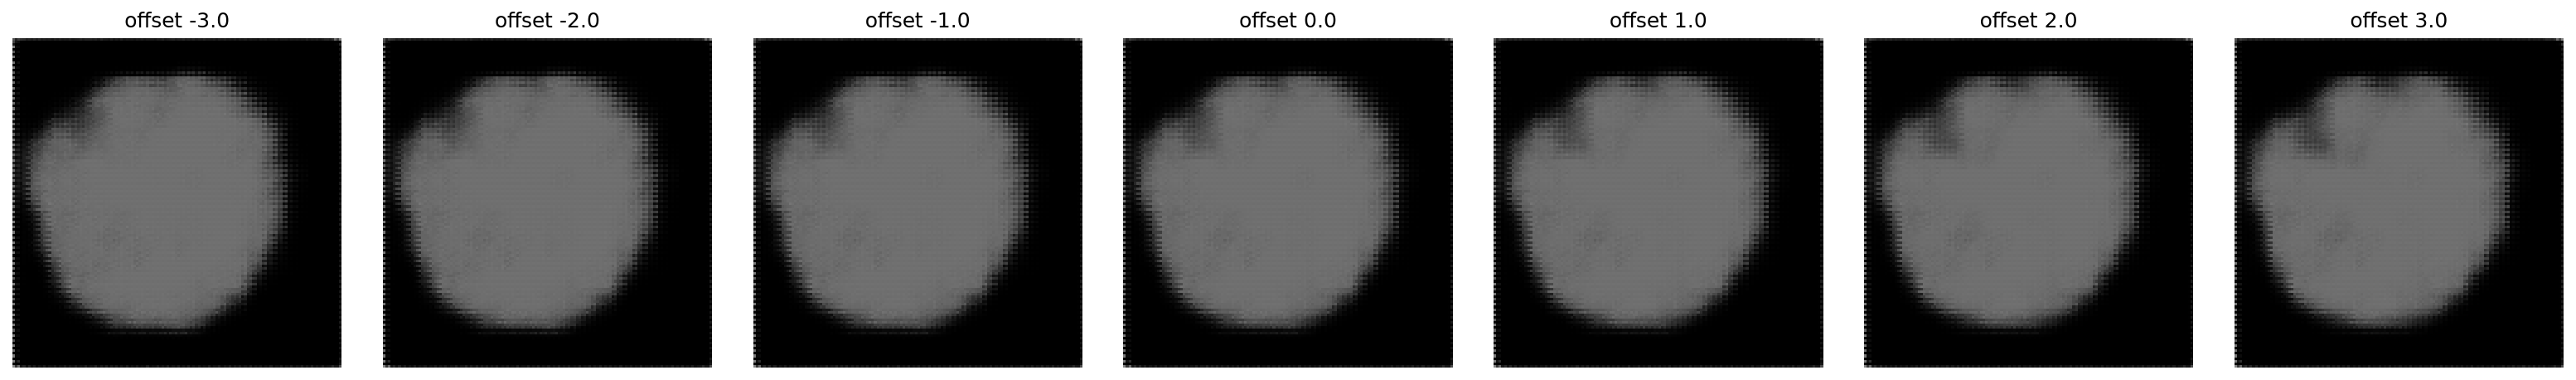

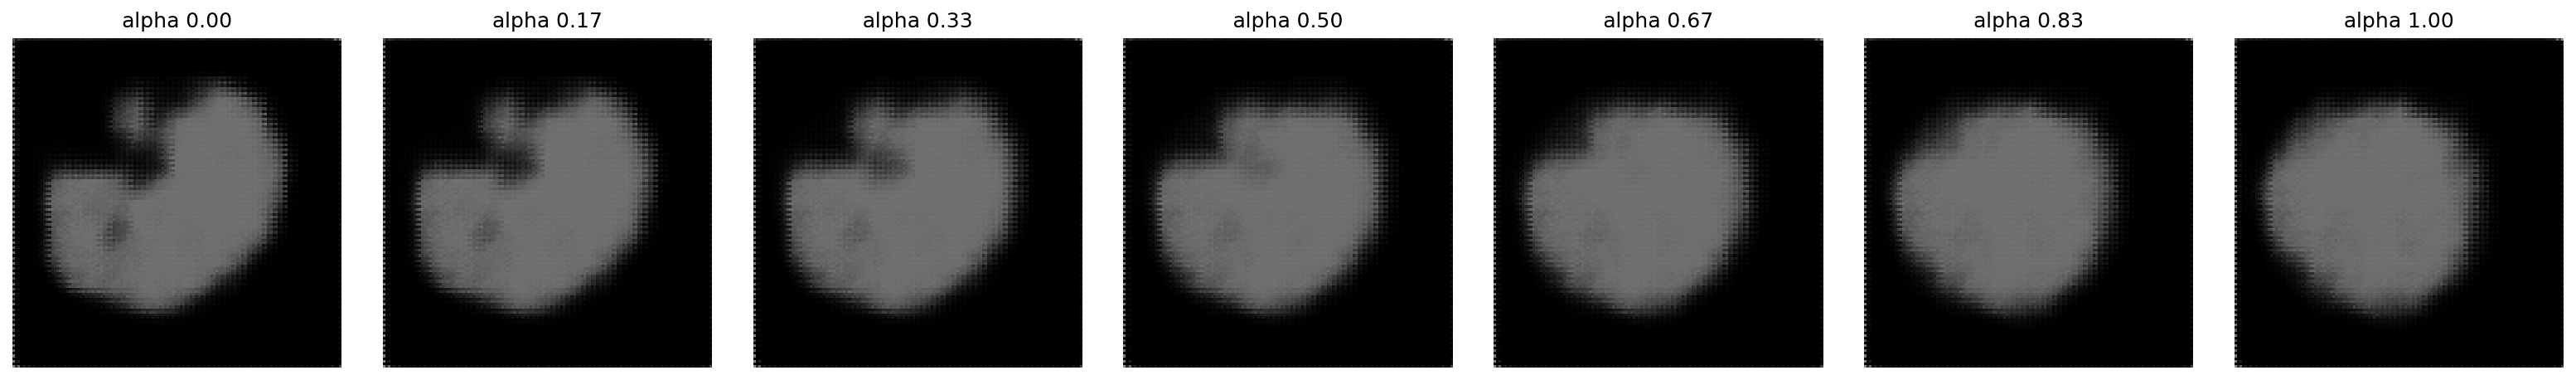

In [9]:
display(Image(filename=str(toy_output / 'latent_traversal.png')))
display(Image(filename=str(toy_output / 'latent_interpolation.png')))


### 6. Relevance and limitations

Latent variations may be useful for compression, anomaly detection, similarity search, or initialization for downstream learning. They must not be interpreted as clinically meaningful variations here: the model was trained on slices from only one synthetic volume, without labels or external validation.


# Analysis

The original tutorial asks for latent codes from different classes and a t-SNE/UMAP plot. Only one scan/class is available, so this notebook uses inferior/middle/superior slice-position thirds as **proxy groups**. These are not diagnostic or biological classes. Download samples from additional AADD classes before drawing conclusions about class separation.


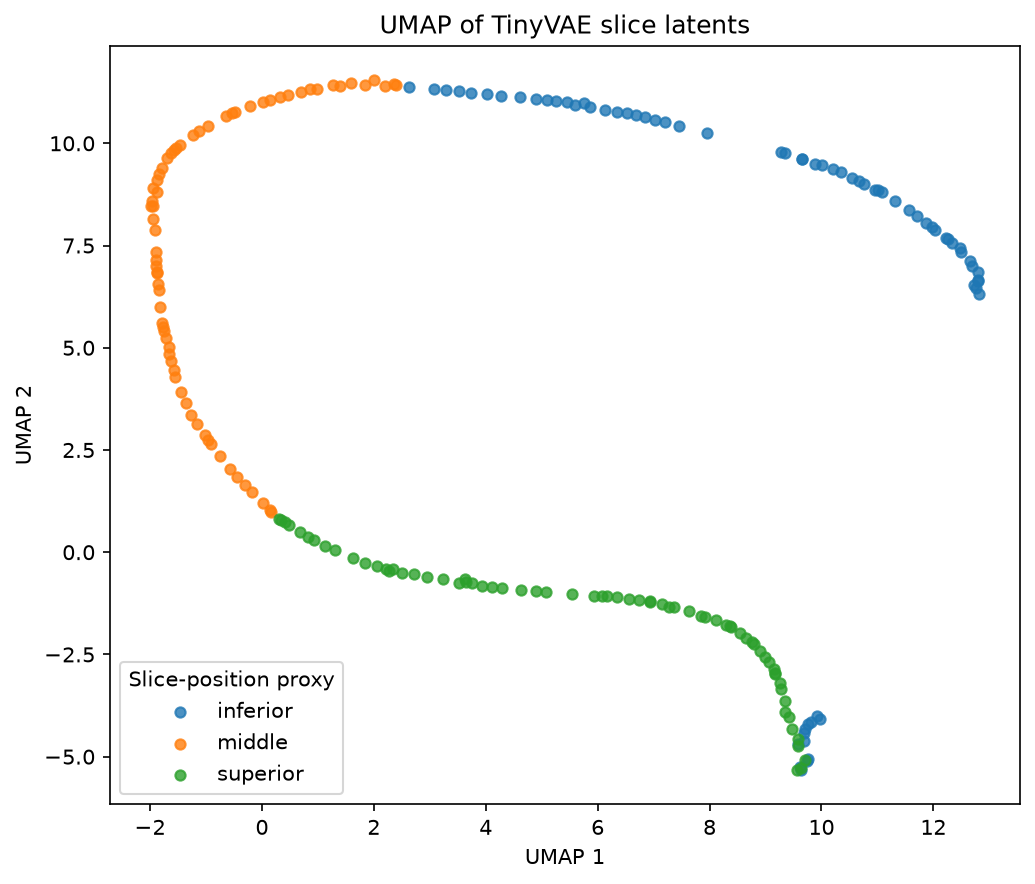

Latent-space silhouette (proxy groups): 0.33602988719940186
Image-space silhouette (proxy groups): 0.24903765320777893


In [10]:
display(Image(filename=str(toy_output / 'latent_umap.png')))
print('Latent-space silhouette (proxy groups):', metrics['latent_silhouette_proxy'])
print('Image-space silhouette (proxy groups):', metrics['image_silhouette_proxy'])


## Interpretation

For this run, the latent-space proxy-group silhouette score is approximately **0.336**, compared with **0.249** for downsampled image space. This suggests that the encoder organizes slices by broad anatomical position somewhat more clearly than raw pixels.

This does **not** demonstrate class discrimination: adjacent slices from the same volume are highly correlated, and the groups were derived from slice position. A valid class experiment requires independent volumes from multiple classes, a train/test split at the volume level, and evaluation on held-out subjects.


In [11]:
# Latent arrays are saved for further experiments.
latent_results = np.load(toy_output / 'latent_codes.npz')
print('Latent matrix:', latent_results['latent'].shape)
print('Slice indices:', latent_results['slice_index'].shape)
print('Proxy groups:', np.unique(latent_results['group'], return_counts=True))


Latent matrix: (207, 16)
Slice indices: (207,)
Proxy groups: (array([0, 1, 2]), array([69, 69, 69]))
